In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Load Data
df = pd.read_csv('../data/banknote-auth.csv', encoding='latin-1')
# Use info function to examine feature names
df.sample(10)

,variance,skewness,kurtosis,entropy,label
402,1.96470,6.93830,0.57722,0.663770,0
1196,-2.01490,3.68740,-1.93850,-3.891800,1
153,3.45910,11.11200,-4.20390,-5.093100,0
303,-1.91770,11.68940,2.54540,-3.276300,0
838,-2.32110,3.16600,-1.00020,-2.715100,1
182,-0.69572,8.61650,1.84190,-4.328900,0
1272,-4.23330,4.91660,-0.49212,-5.320700,1
575,2.61040,8.00810,-0.23592,-1.760800,0
1062,-0.11716,0.60422,-0.38587,-0.059065,1
623,3.77580,7.17830,-1.51950,0.401280,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   kurtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   label     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


<Axes: xlabel='label'>

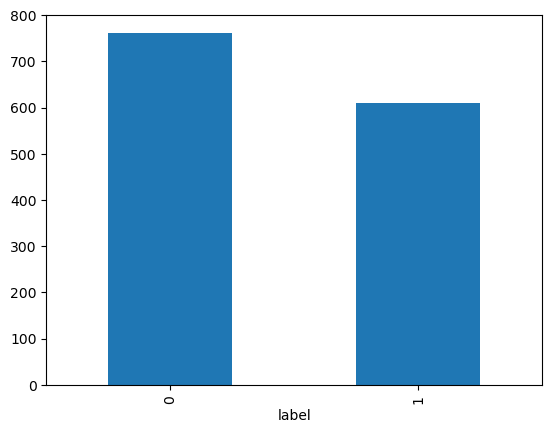

In [28]:
df['label'].value_counts().plot(kind='bar')

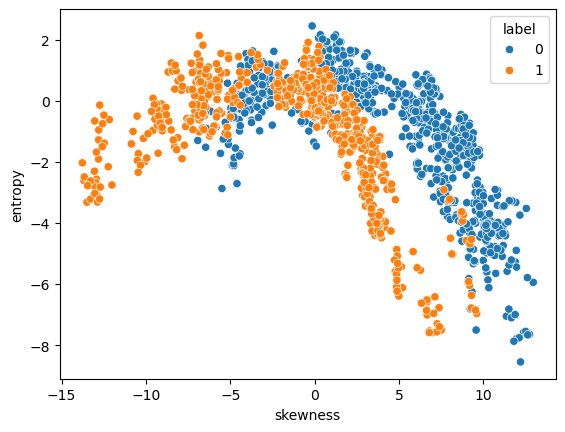

In [29]:
X = df[['skewness', 'entropy']]
y = df['label']
sns.scatterplot(data=df, x='skewness', y='entropy', hue='label')
plt.show()

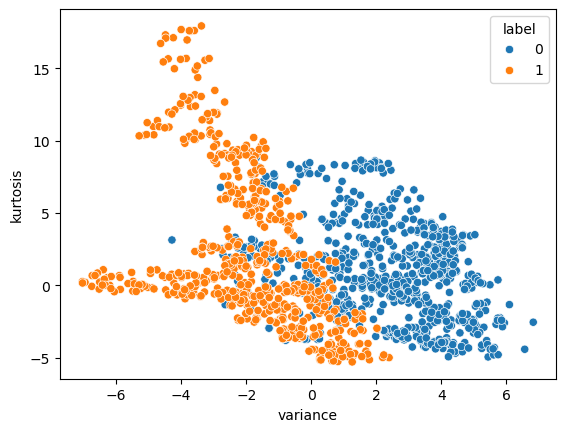

In [30]:
X = df[['variance', 'kurtosis']]
sns.scatterplot(data=df, x='variance', y='kurtosis', hue='label')
plt.show()

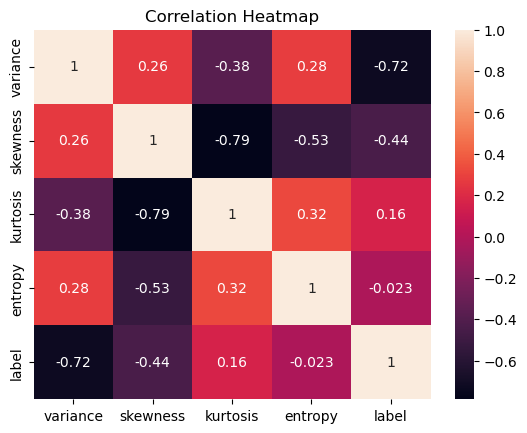

In [31]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

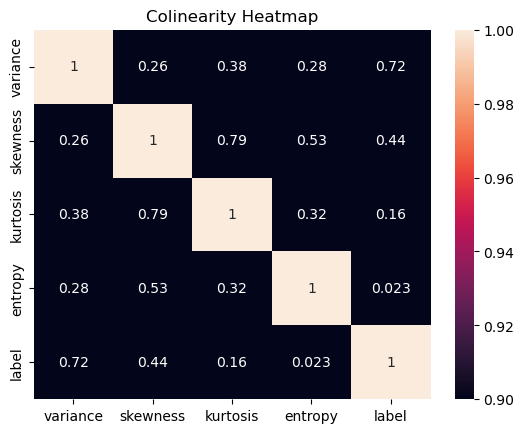

In [32]:
corr = corr.abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.title('Colinearity Heatmap')
plt.show()

**comment on whether any features appear strongly correlated**

No features are strongly correlated, however there is a strong negative correlation with the variance feature. Also, there is no colinearity detected either.

**How balanced are the two classes?**

The two classes are fairly close to balanced with label value 1 measuring about 80-85% of label value 0.

**Which feature pair shows the best separation?**

Honestly, neither seem to have good separation, but if I had to choose skewness and entropy have consistent shapes and may be easiest to predict based on these patterns.

**Does the data appear linearly separable?**

From the EDA, I can say that there is not strong evidence of the data being linearly separable. A straight line cannot be drawn between the two colors in either graph.

**How do you think an MLP will do against a Perceptron on this data?**

With how much overlap there is in the graphs, I think any model would struggle to accurately predict. With fine tuning of the MLP by defining hidden layers and number neurons, we may be able to find decent accuracy, but it doesn't seem like the model will be highly accurate.
